# Brownian Motion (Wiener Process)

Brownian motion, denoted $W(t)$ or $W_t$, is the fundamental building block of stochastic calculus. 
It models the random movement of particles suspended in a fluid and serves as the driving noise 
in financial models, physics, and engineering.

## Mathematical Definition

A **standard Brownian motion** is a stochastic process $\{W(t) : t \geq 0\}$ satisfying:

1. **$W(0) = 0$** (starts at origin)
2. **Independent increments**: For $0 \leq s < t$, the increment $W(t) - W(s)$ is independent of the past
3. **Gaussian increments**: $W(t) - W(s) \sim \mathcal{N}(0, t-s)$
4. **Continuous paths**: $W(t)$ is continuous in $t$ (almost surely)

The probability density of $W(t)$ at any time $t$ is:

$$f_{W(t)}(x) = \frac{1}{\sqrt{2\pi t}} \exp\left(-\frac{x^2}{2t}\right)$$


## Key Statistical Properties

| Property | Formula | Interpretation |
|----------|---------|----------------|
| **Mean** | $\mathbb{E}[W(t)] = 0$ | Unbiased random walk |
| **Variance** | $\text{Var}(W(t)) = t$ | Uncertainty grows linearly with time |
| **Covariance** | $\text{Cov}(W(s), W(t)) = \min(s, t)$ | Overlapping paths are correlated |
| **Quadratic Variation** | $[W, W](t) = t$ | Total "roughness" equals time |
| **Non-differentiability** | $\frac{dW}{dt}$ does not exist | Paths are infinitely jagged |

## Discretization (Euler-Maruyama)

Since Brownian motion is continuous, we simulate it by discretizing time:

$$W(t_{i+1}) = W(t_i) + \Delta W_i$$

where the increment follows:

$$\Delta W_i = \sqrt{\Delta t} \cdot Z_i, \quad Z_i \sim \mathcal{N}(0, 1)$$

This comes from the property that $\text{Var}(\Delta W) = \Delta t$.


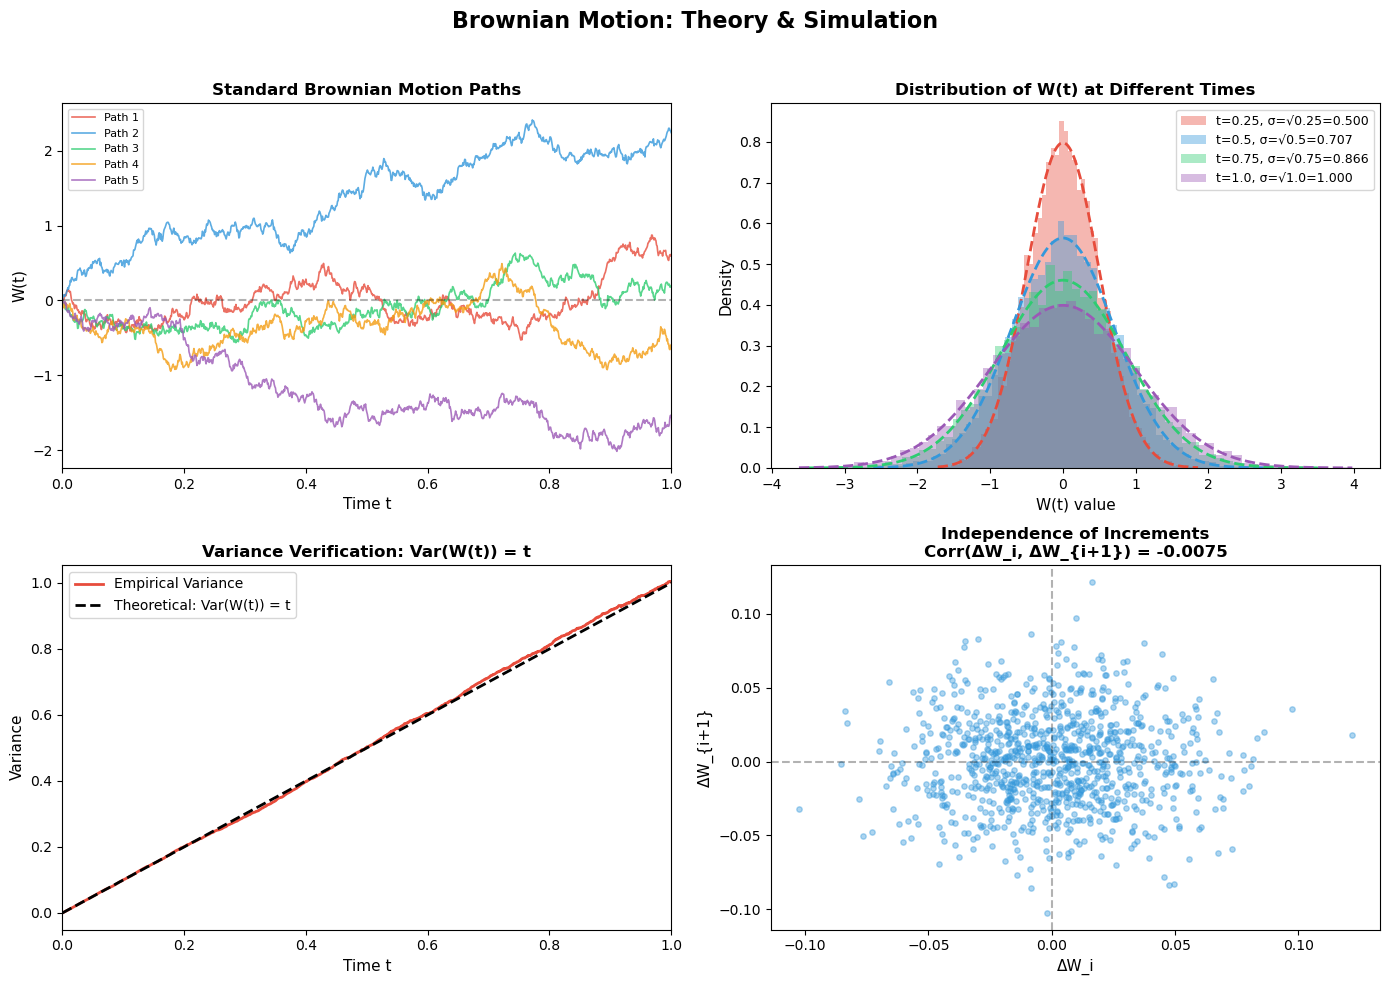

Done! Check the four plots above.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Brownian Motion Simulation (No Seaborn Needed)
# ============================================================

def simulate_brownian_motion(T=1.0, N=1000, n_paths=5, seed=42):
    """
    Simulate standard Brownian motion.
    W(t_{i+1}) = W(t_i) + sqrt(dt) * Z_i
    where Z_i ~ N(0,1)
    """
    np.random.seed(seed)
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate increments: dW ~ N(0, dt)
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    
    # Cumulative sum to get W(t)
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    return t, W

# --- Run simulation ---
T = 1.0
N = 1000
n_paths = 5
t, W = simulate_brownian_motion(T, N, n_paths)

# --- Plot 1: Multiple Sample Paths ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Brownian Motion: Theory & Simulation', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i in range(n_paths):
    ax1.plot(t, W[i], color=colors[i % len(colors)], alpha=0.8, linewidth=1.2, label=f'Path {i+1}')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_title('Standard Brownian Motion Paths', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time t', fontsize=11)
ax1.set_ylabel('W(t)', fontsize=11)
ax1.legend(loc='upper left', fontsize=8)
ax1.set_xlim(0, T)

# --- Plot 2: Distribution of W(t) at different times ---
ax2 = axes[0, 1]
n_simulations = 10000
np.random.seed(123)
dt = T / N
dW_large = np.random.normal(0, np.sqrt(dt), size=(n_simulations, N))
W_large = np.zeros((n_simulations, N + 1))
W_large[:, 1:] = np.cumsum(dW_large, axis=1)

time_points = [0.25, 0.5, 0.75, 1.0]
hist_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for tp, color in zip(time_points, hist_colors):
    idx = int(tp * N)
    values = W_large[:, idx]
    ax2.hist(values, bins=60, alpha=0.4, density=True, color=color, 
             label=f't={tp}, σ=√{tp}={np.sqrt(tp):.3f}')
    
    # Overlay theoretical normal distribution
    x_range = np.linspace(values.min(), values.max(), 200)
    theoretical_pdf = stats.norm.pdf(x_range, 0, np.sqrt(tp))
    ax2.plot(x_range, theoretical_pdf, color=color, linewidth=2, linestyle='--')

ax2.set_title('Distribution of W(t) at Different Times', fontsize=12, fontweight='bold')
ax2.set_xlabel('W(t) value', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(fontsize=9)

# --- Plot 3: Variance over time (verifying Var(W(t)) = t) ---
ax3 = axes[1, 0]
np.random.seed(456)
n_sims = 5000
max_N = 2000
dt_fine = T / max_N
dW_fine = np.random.normal(0, np.sqrt(dt_fine), size=(n_sims, max_N))
W_fine = np.zeros((n_sims, max_N + 1))
W_fine[:, 1:] = np.cumsum(dW_fine, axis=1)

t_fine = np.linspace(0, T, max_N + 1)
empirical_var = np.var(W_fine, axis=0)

ax3.plot(t_fine, empirical_var, color='#e74c3c', linewidth=2, label='Empirical Variance')
ax3.plot(t_fine, t_fine, color='black', linewidth=2, linestyle='--', label='Theoretical: Var(W(t)) = t')
ax3.set_title('Variance Verification: Var(W(t)) = t', fontsize=12, fontweight='bold')
ax3.set_xlabel('Time t', fontsize=11)
ax3.set_ylabel('Variance', fontsize=11)
ax3.legend(fontsize=10)
ax3.set_xlim(0, T)

# --- Plot 4: Increment Analysis (verifying independent increments) ---
ax4 = axes[1, 1]
increments = np.diff(W[0])
ax4.scatter(increments[:-1], increments[1:], alpha=0.4, s=15, color='#3498db')
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax4.axvline(x=0, color='black', linestyle='--', alpha=0.3)

corr = np.corrcoef(increments[:-1], increments[1:])[0, 1]
ax4.set_title(f'Independence of Increments\nCorr(ΔW_i, ΔW_{{i+1}}) = {corr:.4f}', 
              fontsize=12, fontweight='bold')
ax4.set_xlabel('ΔW_i', fontsize=11)
ax4.set_ylabel('ΔW_{i+1}', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Done! Check the four plots above.")


## Why Does $\Delta W_i = \sqrt{\Delta t} \cdot Z_i$?

This is the **crucial step** in the simulation. Let's derive it:

By definition, Brownian motion has independent increments with:

$$W(t_{i+1}) - W(t_i) \sim \mathcal{N}(0, t_{i+1} - t_i) = \mathcal{N}(0, \Delta t)$$

A normal random variable $X \sim \mathcal{N}(\mu, \sigma^2)$ can be written as:

$$X = \mu + \sigma \cdot Z \quad \text{where} \quad Z \sim \mathcal{N}(0, 1)$$

Since $\mu = 0$ and $\sigma^2 = \Delta t$:

$$\Delta W_i = \sqrt{\Delta t} \cdot Z_i$$

This preserves the correct variance structure. If we used $\Delta t \cdot Z_i$ instead, 
the variance would be $(\Delta t)^2$, which is wrong — the paths would be too smooth.


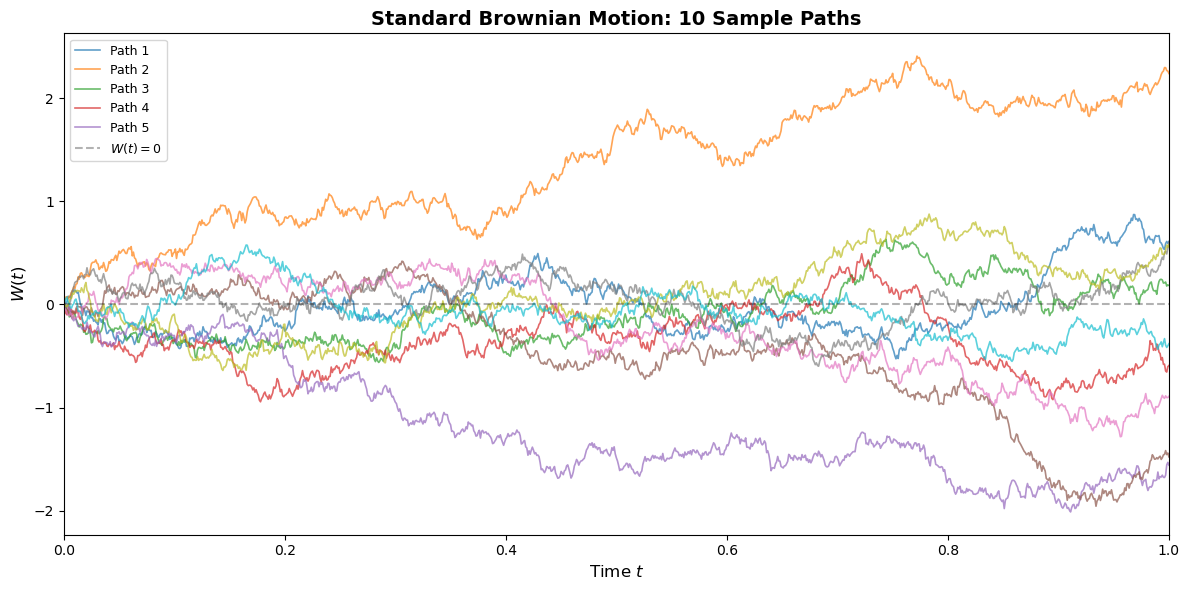

Mean of W(1): -0.0675 (theoretical: 0)
Variance of W(1): 1.1986 (theoretical: 1)
Std of W(1): 1.0948 (theoretical: 1)


In [3]:
# Simulate and plot multiple paths
t, W = simulate_brownian_motion(T=1.0, N=1000, n_paths=10, seed=42)

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.plot(t, W[i], alpha=0.7, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, label='$W(t) = 0$')
plt.title('Standard Brownian Motion: 10 Sample Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('$W(t)$', fontsize=12)
plt.legend(loc='upper left', fontsize=9)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Print endpoint statistics
print(f"Mean of W(1): {np.mean(W[:, -1]):.4f} (theoretical: 0)")
print(f"Variance of W(1): {np.var(W[:, -1]):.4f} (theoretical: 1)")
print(f"Std of W(1): {np.std(W[:, -1]):.4f} (theoretical: 1)")


## Distribution of $W(t)$ at Fixed Times

At any fixed time $t$, $W(t) \sim \mathcal{N}(0, t)$. This means:
- The **mean** stays at 0
- The **standard deviation** grows as $\sqrt{t}$
- The distribution **spreads out** over time

This is fundamentally different from deterministic processes where uncertainty might shrink or stay constant.


# Verify that W(t) follows N(0, t) at different times
n_simulations = 20000
T, N = 1.0, 1000
t, W_large = simulate_brownian_motion(T, N, n_simulations, seed=123)

time_points = [0.25, 0.50, 0.75, 1.00]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for idx, (tp, color, ax) in enumerate(zip(time_points, colors, axes)):
    i = int(tp * N)
    values = W_large[:, i]
    
    # Histogram of simulated values
    ax.hist(values, bins=60, density=True, alpha=0.6, color=color, 
            label=f'Simulated at $t={tp}$')
    
    # Theoretical normal PDF
    x_range = np.linspace(values.min(), values.max(), 200)
    theoretical = stats.norm.pdf(x_range, 0, np.sqrt(tp))
    ax.plot(x_range, theoretical, 'k--', linewidth=2, label=f'Theory: $\\mathcal{{N}}(0, {tp})$')
    
    # Statistics
    empirical_mean = np.mean(values)
    empirical_std = np.std(values)
    
    ax.set_title(f'$t = {tp}$\\n$\\mu = {empirical_mean:.3f}$, $\\sigma = {empirical_std:.3f}$ '
                 f'(theory: $\\sigma = \\sqrt{{{tp}}} = {np.sqrt(tp):.3f}$)', fontsize=11)
    ax.set_xlabel('$W(t)$', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Distribution of $W(t)$ at Different Times', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Covariance and Correlation Structure

For $s \leq t$, the covariance is:

$$\text{Cov}(W(s), W(t)) = \mathbb{E}[W(s)W(t)] = s$$

This can be derived by writing $W(t) = W(s) + (W(t) - W(s))$ and using independence of increments:

$$\mathbb{E}[W(s)W(t)] = \mathbb{E}[W(s)^2] + \mathbb{E}[W(s)(W(t)-W(s))] = s + 0 = s$$

The correlation is:

$$\rho(W(s), W(t)) = \frac{\min(s,t)}{\sqrt{s \cdot t}} = \sqrt{\frac{\min(s,t)}{\max(s,t)}}$$

For $s = t/2$, we get $\rho = 1/\sqrt{2} \approx 0.707$, meaning Brownian motion at nearby times is highly correlated.


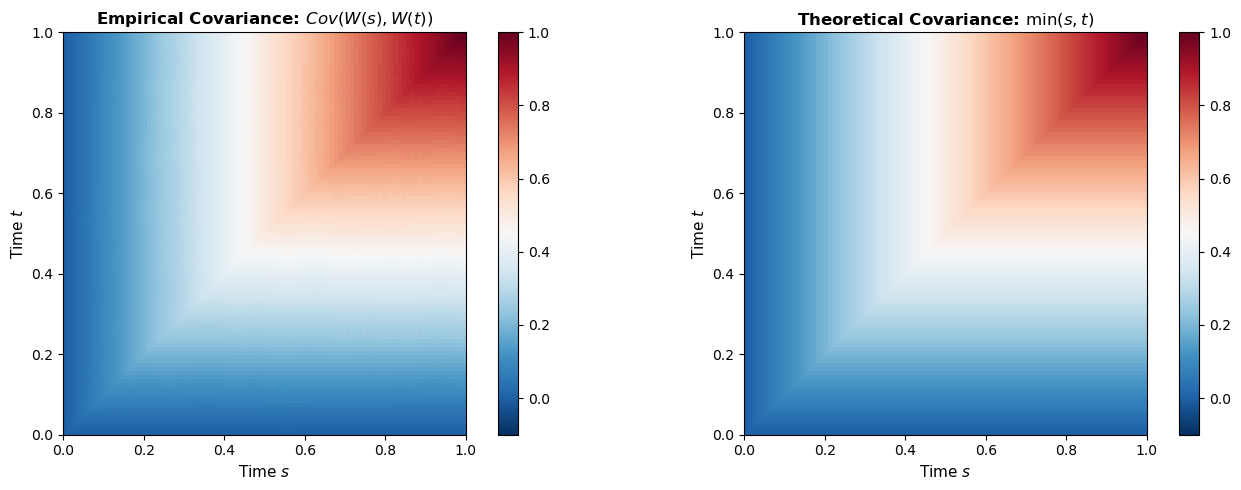

Empirical Cov(W(0.25), W(0.75)) = 0.2569
Theoretical Cov = min(0.25, 0.75) = 0.2500


In [4]:
# Verify covariance structure
n_sims = 10000
t_grid = np.linspace(0, 1, 101)
_, W_cov = simulate_brownian_motion(T=1.0, N=100, n_paths=n_sims, seed=999)

# Compute empirical covariance matrix
empirical_cov = np.cov(W_cov.T)

# Theoretical covariance: min(s, t)
theoretical_cov = np.minimum.outer(t_grid, t_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Empirical covariance heatmap
im1 = axes[0].imshow(empirical_cov, origin='lower', cmap='RdBu_r', 
                     vmin=-0.1, vmax=1.0, extent=[0, 1, 0, 1])
axes[0].set_title('Empirical Covariance: $Cov(W(s), W(t))$', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time $s$', fontsize=11)
axes[0].set_ylabel('Time $t$', fontsize=11)
plt.colorbar(im1, ax=axes[0])

# Theoretical covariance heatmap
im2 = axes[1].imshow(theoretical_cov, origin='lower', cmap='RdBu_r', 
                     vmin=-0.1, vmax=1.0, extent=[0, 1, 0, 1])
axes[1].set_title('Theoretical Covariance: $\\min(s, t)$', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time $s$', fontsize=11)
axes[1].set_ylabel('Time $t$', fontsize=11)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# Check specific values
s_idx, t_idx = 25, 75  # s=0.25, t=0.75
print(f"Empirical Cov(W(0.25), W(0.75)) = {empirical_cov[s_idx, t_idx]:.4f}")
print(f"Theoretical Cov = min(0.25, 0.75) = {min(0.25, 0.75):.4f}")


## Quadratic Variation (The Signature of Randomness)

For a smooth deterministic function $f(t)$, the **total variation** is finite and the 
**quadratic variation** is zero:

$$\sum_{i=1}^{N} (f(t_i) - f(t_{i-1}))^2 \to 0 \quad \text{as } N \to \infty$$

For Brownian motion, something remarkable happens:

$$\sum_{i=1}^{N} (W(t_i) - W(t_{i-1}))^2 \to t \quad \text{as } N \to \infty$$

This **non-zero quadratic variation** is what makes stochastic calculus different from ordinary calculus. 
It explains why we need Itô's lemma instead of the chain rule.


N =    10: Quadratic Variation = 0.932848 (error = 0.067152)
N =    50: Quadratic Variation = 0.988479 (error = 0.011521)
N =   100: Quadratic Variation = 0.883908 (error = 0.116092)
N =   500: Quadratic Variation = 0.949838 (error = 0.050162)
N =  1000: Quadratic Variation = 1.112391 (error = 0.112391)
N =  5000: Quadratic Variation = 1.002429 (error = 0.002429)


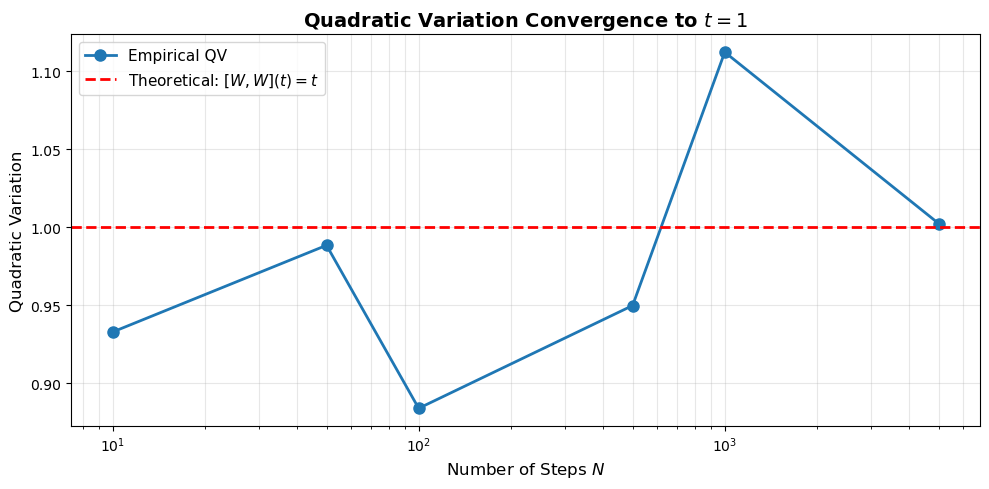

In [5]:
# Demonstrate quadratic variation convergence
np.random.seed(777)
T = 1.0

# Try different numbers of steps
N_values = [10, 50, 100, 500, 1000, 5000]
qv_results = []

for N in N_values:
    dt = T / N
    dW = np.random.normal(0, np.sqrt(dt), N)
    qv = np.sum(dW**2)
    qv_results.append(qv)
    print(f"N = {N:5d}: Quadratic Variation = {qv:.6f} (error = {abs(qv - T):.6f})")

# Plot convergence
plt.figure(figsize=(10, 5))
plt.semilogx(N_values, qv_results, 'o-', markersize=8, linewidth=2, label='Empirical QV')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Theoretical: $[W,W](t) = t$')
plt.xlabel('Number of Steps $N$', fontsize=12)
plt.ylabel('Quadratic Variation', fontsize=12)
plt.title('Quadratic Variation Convergence to $t = 1$', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


# Geometric Brownian Motion (GBM)

GBM extends Brownian motion to model quantities that must stay positive, like stock prices.

## The SDE

$$\frac{dS(t)}{S(t)} = \mu \, dt + \sigma \, dW(t)$$

Where:
- $\mu$ = drift (expected return)
- $\sigma$ = volatility (standard deviation of returns)
- $S(t)$ = price at time $t$

## The Exact Solution (Itô's Lemma)

Unlike most SDEs, GBM has a closed-form solution:

$$S(t) = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)\right]$$

## Why the $-\sigma^2/2$ Term?

This is the **Itô correction**. In ordinary calculus, $d(e^{X}) = e^X dX$, but in stochastic calculus:

$$d(e^{\sigma W(t)}) \neq \sigma e^{\sigma W(t)} dW(t)$$

The extra term $-\sigma^2/2$ ensures that $\mathbb{E}[S(t)] = S_0 e^{\mu t}$, matching our intuition about expected returns.


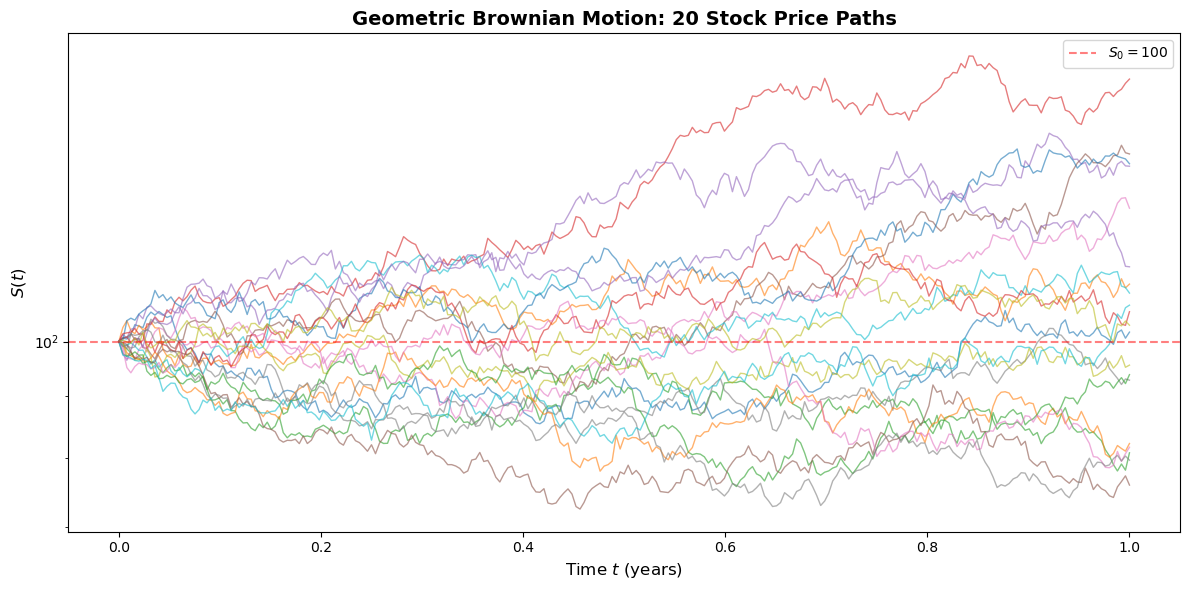

Mean S(1): 107.80 (theory: 105.13)
Median S(1): 104.53
Std S(1): 24.25


In [6]:
def simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=252, n_paths=10, seed=None):
    """
    Simulate Geometric Brownian Motion.
    
    Uses the exact solution to avoid discretization error:
    S(t) = S0 * exp((mu - sigma^2/2)*t + sigma*W(t))
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate Brownian motion
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # Apply GBM solution formula
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    
    return t, S

# Simulate stock prices
t, S = simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=252, n_paths=20, seed=42)

plt.figure(figsize=(12, 6))
for i in range(20):
    plt.plot(t, S[i], alpha=0.6, linewidth=1)

plt.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='$S_0 = 100$')
plt.title('Geometric Brownian Motion: 20 Stock Price Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$ (years)', fontsize=12)
plt.ylabel('$S(t)$', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log')  # Log scale helps visualize proportional changes
plt.tight_layout()
plt.show()

# Statistics at T=1
print(f"Mean S(1): {np.mean(S[:, -1]):.2f} (theory: {100 * np.exp(0.05):.2f})")
print(f"Median S(1): {np.median(S[:, -1]):.2f}")
print(f"Std S(1): {np.std(S[:, -1]):.2f}")


## Why Stock Prices Follow a Log-Normal Distribution

Since $S(t) = S_0 \exp(\ldots)$ and the exponent is normally distributed, $S(t)$ follows a 
**log-normal distribution**:

$$\ln(S(t)) \sim \mathcal{N}\left(\ln(S_0) + \left(\mu - \frac{\sigma^2}{2}\right)t, \; \sigma^2 t\right)$$

Key properties:
- **Always positive**: $S(t) > 0$ (good for prices!)
- **Right-skewed**: Large upward moves are possible, but bounded below at 0
- **Expected value**: $\mathbb{E}[S(t)] = S_0 e^{\mu t}$
- **Median**: $S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t\right]$ (less than the mean)
- 

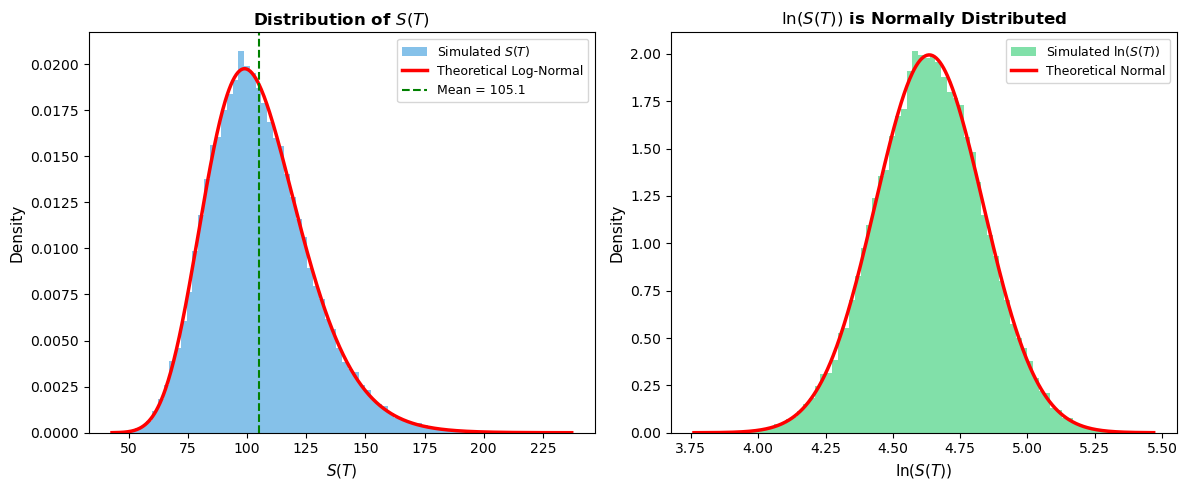

Skewness of S(T): 0.611 (log-normal is right-skewed)
Kurtosis of S(T): 0.635


In [7]:
# Verify log-normal distribution of S(T)
n_sims = 50000
t, S_large = simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=252, n_paths=n_sims, seed=123)
S_T = S_large[:, -1]

# Plot distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(S_T, bins=80, density=True, alpha=0.6, color='#3498db', label='Simulated $S(T)$')

# Theoretical log-normal PDF
log_mean = np.log(100) + (0.05 - 0.5*0.2**2)*1.0
log_std = 0.2 * np.sqrt(1.0)
x_range = np.linspace(S_T.min(), S_T.max(), 500)
theoretical = stats.lognorm.pdf(x_range, s=log_std, scale=np.exp(log_mean))
plt.plot(x_range, theoretical, 'r-', linewidth=2.5, label='Theoretical Log-Normal')

plt.axvline(x=100*np.exp(0.05), color='green', linestyle='--', 
            label=f'Mean = {100*np.exp(0.05):.1f}')
plt.title('Distribution of $S(T)$', fontsize=12, fontweight='bold')
plt.xlabel('$S(T)$', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=9)

# Log-scale plot
plt.subplot(1, 2, 2)
plt.hist(np.log(S_T), bins=80, density=True, alpha=0.6, color='#2ecc71', label='Simulated $\\ln(S(T))$')
x_log = np.linspace(np.log(S_T).min(), np.log(S_T).max(), 500)
plt.plot(x_log, stats.norm.pdf(x_log, log_mean, log_std), 'r-', linewidth=2.5, 
         label='Theoretical Normal')
plt.title('$\\ln(S(T))$ is Normally Distributed', fontsize=12, fontweight='bold')
plt.xlabel('$\\ln(S(T))$', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Skewness of S(T): {stats.skew(S_T):.3f} (log-normal is right-skewed)")
print(f"Kurtosis of S(T): {stats.kurtosis(S_T):.3f}")


## Itô's Lemma: The Fundamental Theorem

If $X(t)$ follows an Itô process:

$$dX(t) = \mu(X,t) \, dt + \sigma(X,t) \, dW(t)$$

And $Y(t) = f(X(t), t)$, then:

$$df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x} dX + \frac{1}{2}\frac{\partial^2 f}{\partial x^2} (dX)^2$$

The **crucial difference** from ordinary calculus is the extra term $\frac{1}{2}f''(dX)^2$. 
Since $(dW)^2 = dt$ in the mean-square sense, this term does **not** vanish.

## Application to GBM

For $S(t) = S_0 e^{X(t)}$ where $dX = (\mu - \sigma^2/2)dt + \sigma dW$:

$$dS = S \, dX + \frac{1}{2} S \, (dX)^2 = S\left[\mu \, dt + \sigma \, dW\right]$$

This confirms our SDE and explains the Itô correction term.


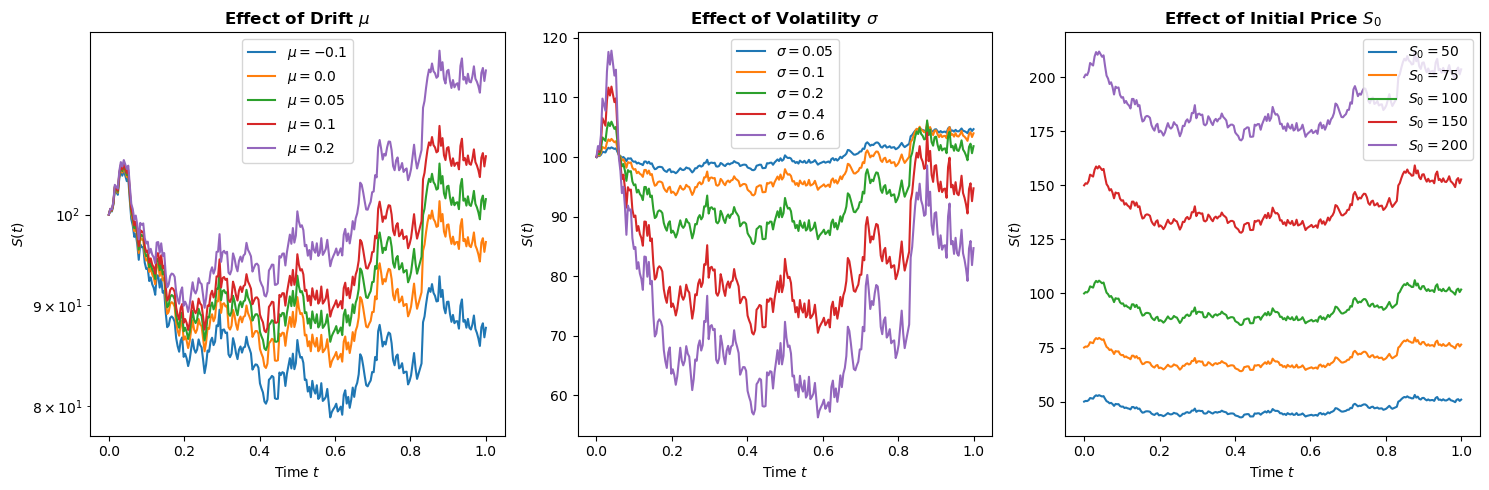

In [8]:
# Experiment with different parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Effect of drift mu
mu_values = [-0.1, 0.0, 0.05, 0.1, 0.2]
for mu in mu_values:
    t, S = simulate_gbm(S0=100, mu=mu, sigma=0.2, T=1.0, N=252, n_paths=1, seed=42)
    axes[0].plot(t, S[0], label=f'$\\mu = {mu}$')
axes[0].set_title('Effect of Drift $\\mu$', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('$S(t)$')
axes[0].legend()
axes[0].set_yscale('log')

# Effect of volatility sigma
sigma_values = [0.05, 0.1, 0.2, 0.4, 0.6]
for sig in sigma_values:
    t, S = simulate_gbm(S0=100, mu=0.05, sigma=sig, T=1.0, N=252, n_paths=1, seed=42)
    axes[1].plot(t, S[0], label=f'$\\sigma = {sig}$')
axes[1].set_title('Effect of Volatility $\\sigma$', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('$S(t)$')
axes[1].legend()

# Effect of initial price S0
S0_values = [50, 75, 100, 150, 200]
for s0 in S0_values:
    t, S = simulate_gbm(S0=s0, mu=0.05, sigma=0.2, T=1.0, N=252, n_paths=1, seed=42)
    axes[2].plot(t, S[0], label=f'$S_0 = {s0}$')
axes[2].set_title('Effect of Initial Price $S_0$', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Time $t$')
axes[2].set_ylabel('$S(t)$')
axes[2].legend()

plt.tight_layout()
plt.show()


|  Concept  |  Formula  |
|-----------|-----------|
|  Brownian increment  |  $\Delta W = \sqrt{\Delta t} \cdot Z$  |
|  W(t) distribution  |  $\mathcal{N}(0, t)$  |
|  Covariance  |  $\min(s, t)$  |
|  Quadratic variation  |  $[W,W](t) = t$  |
|  GBM solution	 |  $S(t) = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)\right]$  |
|  GBM expected value  |  $\mathbb{E}[S(t)] = S_0 e^{\mu t}$  |
 